In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [369]:
features = pd.read_excel('features1.xlsx')
targets = pd.read_excel('targets.xlsx')

features = features.rename(columns={'Unnamed: 0': 'projekti_id'})
targets = targets.rename(columns={'project': 'projekti_id'})

feat_proj = set(features['projekti_id'])
tar_proj = set(targets['projekti_id'])

print(feat_proj - tar_proj)
print(tar_proj - feat_proj)

model_df = features.merge(targets, on='projekti_id', how='inner')

model_df.drop(['Unnamed: 0.1', 'Unnamed: 0'], axis=1, inplace=True)

{'0385 Jysk Hyvinkää_94'}
set()


In [436]:
sdf = model_df.copy()

In [437]:
# lisätään projektien kokonaisukulut -sarake

sdf['totals'] = sdf.iloc[:, 10:].sum(axis=1)

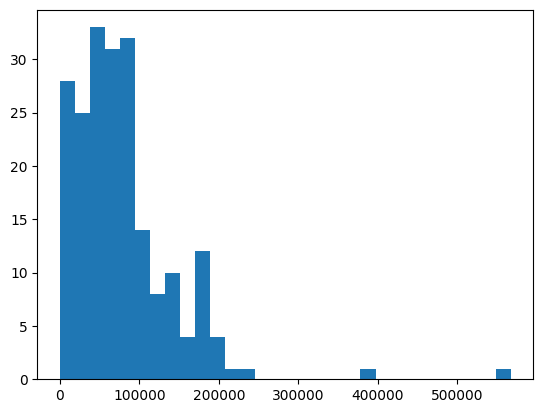

In [438]:
plt.hist(sdf['totals'], bins=30);

In [439]:
# poistetaan nollasarakkeet ja yli 230t€ urakat jotka eivät edusta normaalia profiilia

mask = (sdf['totals'] < 10000) | (sdf['totals'] > 230000)
sdf = sdf[~mask]

Projekteja: 181


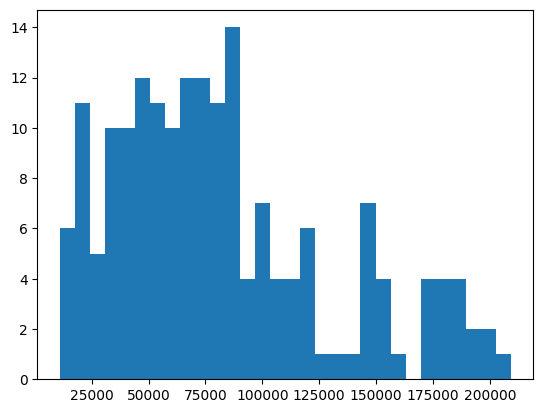

In [440]:
print("Projekteja:", sdf.shape[0])
plt.hist(sdf['totals'], bins=30);

In [441]:
# muutama tier jäänyt 0, muutetaan 1

sdf['tier'] = sdf['tier'].apply(lambda x: 1 if x == 0 else x)

In [442]:
cm = sdf.iloc[:, 1:-1].corr()

<Axes: >

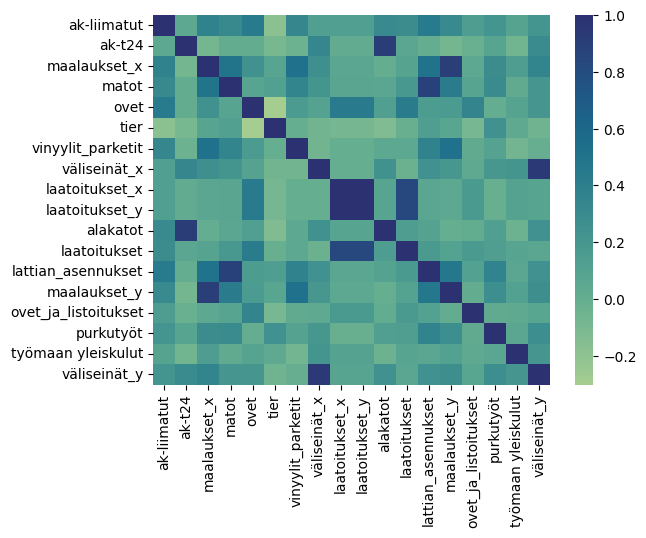

In [443]:
sns.heatmap(cm, cmap='crest')

In [444]:
cm[(cm > .4) & (cm < .9)].iloc[:, 10:]

,alakatot,laatoitukset,lattian_asennukset,maalaukset_y,ovet_ja_listoitukset,purkutyöt,työmaan yleiskulut,väliseinät_y
ak-liimatut,NaN,NaN,0.435889,NaN,NaN,NaN,NaN,NaN
ak-t24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
maalaukset_x,NaN,NaN,0.504409,0.899941,NaN,NaN,NaN,NaN
matot,NaN,NaN,0.885370,0.429030,NaN,NaN,NaN,NaN
ovet,NaN,0.427330,NaN,NaN,NaN,NaN,NaN,NaN
tier,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
vinyylit_parketit,NaN,NaN,NaN,0.520726,NaN,NaN,NaN,NaN
väliseinät_x,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
laatoitukset_x,NaN,0.835723,NaN,NaN,NaN,NaN,NaN,NaN
laatoitukset_y,NaN,0.835723,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
"""
Purkutyöt ja työmaan yleiskulut ovat kohtalaisen tasaisesti jakautuneet featurejen kesken, kute sopisi odottaa.
Ovet ja listoitukset ovat jakautuneet tasaisesti.
Tier, eli työmaan aloitustaso on jakautunut tasaisesti, mikä on hyvä.
"""

In [445]:
# eri työvaiheiden prosenttiosuudet kokonaissummista
numeric_cols = sdf.select_dtypes(include=np.number).columns
pct_df = sdf[numeric_cols].div(sdf['totals'], axis=0) * 100

pct_df = pct_df.iloc[:, 10:-1]
pct_df = pct_df.apply(lambda x: round(x, 1))
pct_df.dropna(inplace=True)

In [446]:
'''
prosenttiosuudet:
työmaan yleiskulut olivat 25 % työmaista 13.5% tai alle kokonaiskuluista, 50 % työmaista 19.7 % tai alle, ja
75 % työmaista 28.1 % tai alle. yleisesti ottaen yleiskulujen osuus työmaista on suhteettoman suuri.
'''
pct_df.describe().T.iloc[:, 1:]



,mean,std,min,25%,50%,75%,max
alakatot,8.057459,13.164920,0.0,0.0,5.5,10.9,100.0
laatoitukset,4.134807,6.591885,0.0,0.0,0.3,7.6,46.4
lattian_asennukset,14.864641,11.950698,0.0,4.3,14.9,22.1,57.9
maalaukset_y,16.803867,12.725850,0.0,10.5,15.3,19.3,88.9
ovet_ja_listoitukset,3.400552,6.466155,0.0,0.0,2.5,4.2,80.8
purkutyöt,11.479558,9.355917,0.0,1.7,11.4,19.2,35.2
työmaan yleiskulut,23.975691,18.357985,0.0,14.0,19.7,27.3,100.0
väliseinät_y,17.278453,14.635134,0.0,8.3,16.2,23.6,100.0


In [447]:
print(f'yleiskulut keskiarvo: {sdf['työmaan yleiskulut'].mean():.2f}')
print(f'yleiskulut mediaani: {sdf['työmaan yleiskulut'].median():.2f}')
print(f'totals keskiarvo: {sdf['totals'].mean():.2f}')
print(f'totals mediaani: {sdf['totals'].median():.2f}')

yleiskulut keskiarvo: 17125.96
yleiskulut mediaani: 14240.53
totals keskiarvo: 81759.76
totals mediaani: 72186.51


In [457]:
sdf[(50000 < sdf['totals'])].iloc[:, 10:].describe().T

,count,mean,std,min,25%,50%,75%,max
laatoitukset_y,129.0,20.298450,38.817457,0.000000,0.000000,0.000000,36.000000,355.000000
alakatot,129.0,10154.007549,14656.955431,0.000000,1574.555556,6040.555556,11896.470588,92910.000000
laatoitukset,129.0,4516.795178,6222.444278,0.000000,0.000000,2955.555556,7298.666667,47500.835294
lattian_asennukset,129.0,18001.659992,17214.081631,0.000000,6491.888889,14607.188889,21964.705882,84120.000000
maalaukset_y,129.0,14796.458689,8773.845370,0.000000,8665.466667,13452.777778,17932.033333,35787.722222
ovet_ja_listoitukset,129.0,3569.294560,6097.900777,0.000000,1093.717647,2601.327807,4760.155556,63904.933333
purkutyöt,129.0,11399.261337,8861.926380,0.000000,3766.666667,11023.333333,17774.812834,38839.869281
työmaan yleiskulut,129.0,20062.913469,19123.054259,0.000000,11887.058824,16117.055556,22660.444444,162507.400000
väliseinät_y,129.0,19128.498325,17957.021170,0.000000,8896.171526,15070.228206,23232.191591,109056.107765
totals,129.0,101649.187549,42504.064778,50148.355556,69208.291111,85708.969778,122742.271108,209218.127778


(array([110.,  59.,   8.,   2.,   0.,   0.,   0.,   0.,   1.,   1.]),
 array([     0.  ,  16250.74,  32501.48,  48752.22,  65002.96,  81253.7 ,
         97504.44, 113755.18, 130005.92, 146256.66, 162507.4 ]),
 <BarContainer object of 10 artists>)

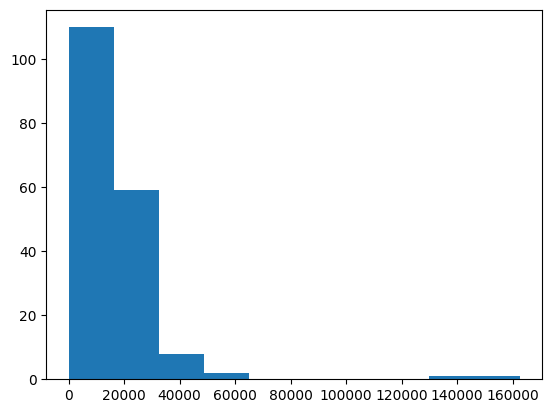

In [463]:
plt.hist(sdf['työmaan yleiskulut'])

In [470]:
mask = sdf['työmaan yleiskulut'] > 45000
sdf = sdf[~mask]

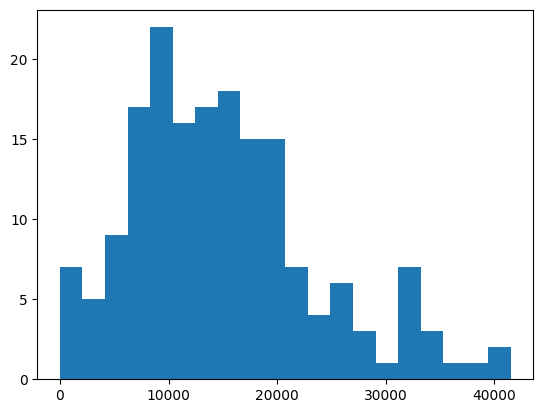

In [471]:
plt.hist(sdf['työmaan yleiskulut'], bins=20);

In [ ]:
cols = list(sdf.iloc[:, 11:-1].columns)

for col in cols:
    plt.hist(sdf[col], bins=20)
    plt.title(f'{col}')
    plt.show();

# jokainen kategoria sisältää outliereitä, poistetaan selkeät profiilin ulkopuoliset työt

In [491]:
cols

['alakatot',
 'laatoitukset',
 'lattian_asennukset',
 'maalaukset_y',
 'ovet_ja_listoitukset',
 'purkutyöt',
 'työmaan yleiskulut',
 'väliseinät_y']

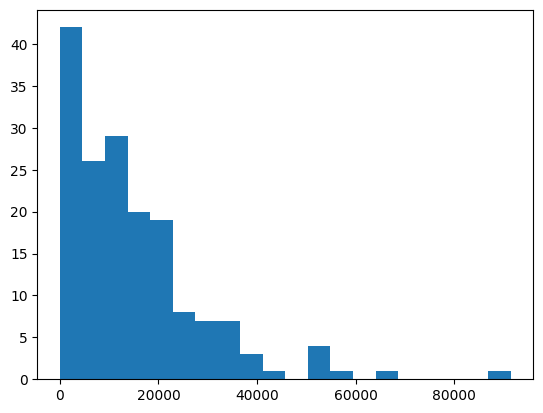

In [512]:
plt.hist(sdf['väliseinät_y'], bins=20);

In [514]:
sdf[sdf['väliseinät_y'] > 90000]

,projekti_id,ak-liimatut,ak-t24,maalaukset_x,matot,ovet,tier,vinyylit_parketit,väliseinät_x,laatoitukset_x,laatoitukset_y,alakatot,laatoitukset,lattian_asennukset,maalaukset_y,ovet_ja_listoitukset,purkutyöt,työmaan yleiskulut,väliseinät_y,totals
94,0385 Jysk Hyvinkää_95,0.0,84.0,2608,0,0,3,0,949.0,0.0,0.0,4607.611111,0.0,0.0,24272.388889,0.0,18788.888889,35429.888889,91494.416327,174593.194105


In [ ]:
"""
ei poisteta:
laatoitukset
lattian asennukset
maalaukset
ovet ja listoitukset, työt näyttävätä olevan linjassa
purkutyöt

vaikka osa kuluista on periaatteessa outliereitä, niin niiden suhde kokonaisuuteen on kuitenkin lineaarinen,
ja koska käytännössä koko datasetin suhde on lineaarinen, ei outliereiden poistoon ole syytä, ellei kyseinen
projekti muuten ole syystä tai toisesta poikkeava. Jos projekti on liiketoiminnallisesti looginen ja sopii
yrityksen profiiliin, niin se kannattaa pitää datasetissä ja korkeintaan liputtaa tutkimisen arvoiseksi mallin
lopputuloksessa.

tapausesimerkkinä Jysk Hyvinkää: projektin väliseinät olivat huomattavan kallis, mutta kyseessä on ~2500m2
myymäläremontti, joten on perusteltua että väliseinäkustannukset ovat erityisen suuret. Projekti on yrityksen
profiilin mukainen ja looginen tavoite liiketoiminnallisesti. Huomataan kuitenkin, että väliseinärakenteet
poikkeavat huomattavasti muiden projektien väliseinistä, ne ovat korkeammat ja murtovahistetut. Tämä ei siis
anna vertailukelpoista dataa mallille, vaan isona poikkeavana kokonaisuutena se vääristäisi mallin väliseinä-
kertoimia. Päätetään poistaa kohde.
"""
mask = sdf['alakatot'] > 40000
sdf = sdf[~mask]
mask = sdf['väliseinät_y'] > 90000
sdf = sdf[~mask]

In [517]:
sdf.to_excel('valmis_dataset.xlsx', engine='openpyxl')